In [1]:
import torch
from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\26911\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\26911\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

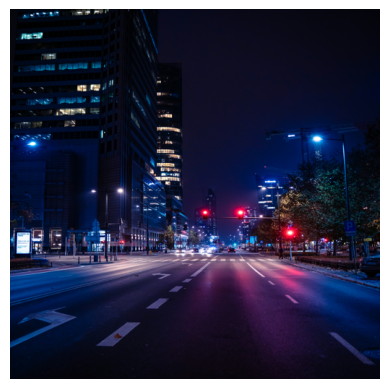

In [4]:
image_path = "C:/Users/26911/Desktop/diffusion_style_project/data/content/content_001.jpg"

init_image = Image.open(image_path).convert("RGB")
init_image = init_image.resize((512,512))

plt.imshow(init_image)
plt.axis("off")

In [5]:
strength_values = [0.3, 0.6, 0.9]

In [6]:
results = []

prompt = "a painting in the style of Vincent van Gogh"

for s in strength_values:

    output = pipe(
        prompt=prompt,
        image=init_image,
        strength=s,
        guidance_scale=7.5
    )

    results.append(output.images[0])

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

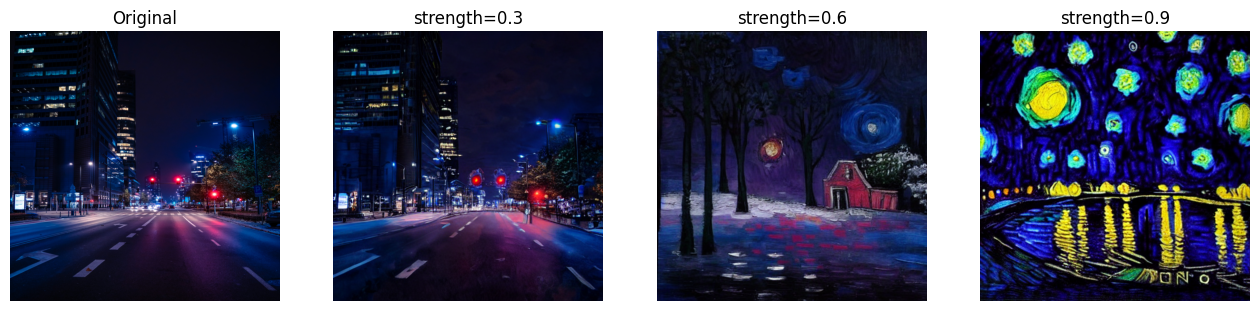

In [7]:
fig, ax = plt.subplots(1,4, figsize=(16,5))

ax[0].imshow(init_image)
ax[0].set_title("Original")
ax[0].axis("off")

for i, img in enumerate(results):

    ax[i+1].imshow(img)
    ax[i+1].set_title(f"strength={strength_values[i]}")
    ax[i+1].axis("off")

In [8]:
for i, img in enumerate(results):

    img.save(f"C:/Users/26911/Desktop/diffusion_style_project/results/strength_{strength_values[i]}.png")